<a href="https://www.kaggle.com/code/mdabdulalhasib/image-segmentation-analysis-airbus-ship-challeng?scriptVersionId=308359314" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [63]:
import os


data_root: str = "/kaggle/input/competitions/airbus-ship-detection"
print(f"The root of the data: '{data_root}'")
print(f"Items of the root dir: {os.listdir(data_root)}")

The root of the data: '/kaggle/input/competitions/airbus-ship-detection'
Items of the root dir: ['test_v2', 'sample_submission_v2.csv', 'train_ship_segmentations_v2.csv', 'train_v2']


In [64]:
import cv2
import albumentations
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
import tqdm

class csv: ... # place holder for type annotation
class AirbusShipDataset(Dataset):

    def __init__(self, imgs_root: str, masks_root: csv):
        
        super().__init__()
        self.imgs_root = imgs_root
        
        new_masks_root: str = "/kaggle/working/_inter_mask"
        os.makedirs(new_masks_root, exist_ok = True)
        self.masks_root = new_masks_root
        self.mask_infos = self._prepMasks(masks_root, new_masks_root)
        
    def _prepMasks(self, masks_root: str, to: str) -> pd.DataFrame:
      
        masks = pd.read_csv(masks_root)
        os.makedirs(to, exist_ok=True)
    
        data_list = []
        groups = masks.groupby("ImageId")
        
        for image_id, group in tqdm.tqdm(groups):
            rles = group["EncodedPixels"].dropna()
            ship_count = len(rles)
        
            if ship_count > 0:
                mask = np.zeros(768 * 768, dtype=np.uint8)
                
                for rle in rles:
                    starts_lens = rle.split()
                    starts = np.asarray(starts_lens[::2], dtype=int) - 1
                    lens = np.asarray(starts_lens[1::2], dtype=int)
                    
                    for start, length in zip(starts, lens):
                        mask[start: start+length] = 1 

                mask_path = os.path.join(to, f"{image_id}.npy")
                np.save(mask_path, np.packbits(mask))
            
                data_list.append({
                    "ImageId": image_id,
                    "ShipCounts": ship_count,
                    "MaskPath": mask_path
                })
            else:
                data_list.append({
                    "ImageId": image_id,
                    "ShipCounts": 0,
                    "MaskPath": None
                })
            
        return pd.DataFrame(data_list)

In [65]:
dataset = AirbusShipDataset(imgs_root = os.path.join(data_root, "train_v2"),
                            masks_root = os.path.join(data_root, "train_ship_segmentations_v2.csv"))


100%|██████████| 192556/192556 [00:45<00:00, 4239.15it/s]


In [66]:
import cv2

class ImageDataset(Dataset):

    def __init__(self, src: AirbusShipDataset, indices: list[int], transform = None):
        super().__init__()
        
        self.imgs_root = src.imgs_root 
        self.masks_root = src.masks_root
        
        self.imgids = src.mask_infos["ImageId"].values
        self.mask_paths = src.mask_infos["MaskPath"].values
        self.ship_counts  = src.mask_infos["ShipCounts"].values
        
        self.indices = indices
        self.transform = transform
        
    def __len__(self) -> int:
        return len(self.indices)
    
    def __getitem__(self, index: int) -> tuple:

        index = self.indices[index]
        image_path = os.path.join(self.imgs_root ,  self.imgids[index])
        mask_path = self.mask_paths[index]
            
        image = cv2.imread(image_path, cv2.IMREAD_COLOR_RGB)

        mask = None
        if mask_path is None:
            mask = np.zeros(768 * 768)
        else:
            mask = np.unpackbits(np.load(mask_path))[: 768 * 768]
        mask = mask.reshape((768, 768), order = "F")
        
        ship_counts = self.ship_counts[index]
        
        if self.transform:
            argmt = self.transform(image = image, mask = mask)
            image = argmt["image"]
            mask = argmt["mask"]
            mask = mask.float()
            
        n_ship_pixels = mask.sum().item()

        n_ship_pixels = torch.tensor(n_ship_pixels, dtype = torch.float32)
        ship_counts = torch.tensor(ship_counts, dtype = torch.float32)
        return image, mask, ship_counts, n_ship_pixels

In [67]:
import albumentations as A

train_tf: A.Compose = A.Compose([
    A.RandomResizedCrop((512, 512), interpolation= cv2.INTER_LINEAR, scale = (0.6 , 1.0)),
    A.HorizontalFlip(p = 0.5),
    A.VerticalFlip(p = 0.5),
    A.RandomRotate90(p = 0.4),
    A.ShiftScaleRotate((-0.1, 0.1), (-0.1, 0.2), (-30, 30)),
    A.GridDistortion(num_steps = 10),
    A.ElasticTransform(alpha = 2, sigma = 30),
    A.ColorJitter((0.7 , 1.0), (0.7 , 1.0), (0.8 , 1.2), hue = (-0.1, 0.1), p = 0.3),
    A.OneOf([
         A.GaussNoise( std_range = (0.03, 0.07), p = 0.2),
         A.ISONoise( p = 0.4),
    ], p = 1.0),
    A.OneOf([
        A.GaussianBlur((3, 5), p = 0.5),
        A.MotionBlur((3, 5), p = 0.5),
        A.MedianBlur((3, 5), p = 0.5)
    ], p = 1.0),
    A.OneOf([
         A.RandomFog(fog_coef_range  = (0.1, 0.3), p = 0.4),
         A.RandomShadow(num_shadows_limit = (1,3), p = 0.1),
         A.Solarize(threshold_range = (0.8, 0.9), p = 0.1),
    ], p = 1.0),
    
    A.CoarseDropout((4, 8), (8 , 16), (8 , 16), p = 0.07),
    A.Normalize(),
    A.pytorch.transforms.ToTensorV2()
])

test_tf: A.Compose = A.Compose([
    A.CenterCrop(height = 512, width = 512, border_mode = cv2.BORDER_REFLECT_101),
    A.Normalize(),
    A.pytorch.transforms.ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [68]:
from sklearn.model_selection import train_test_split


all_indices = list(range(len(dataset.mask_infos)))
has_ships = dataset.mask_infos['ShipCounts'] > 0

train_indices, val_indices, _ , _ = train_test_split(
    all_indices,
    all_indices,
    train_size = 0.7,
    test_size = 0.3,
    random_state = 13,
    shuffle = True,
    stratify = has_ships
)

print(f"Train indices peak: {train_indices[:5]}, size = {len(train_indices)}")
print(f"Validation indices peak: {val_indices[:5]}, size = {len(val_indices)}")

Train indices peak: [9134, 71381, 70884, 100104, 182186], size = 134789
Validation indices peak: [2172, 157885, 162888, 111731, 89892], size = 57767


In [69]:
TrainingDataset = ImageDataset(dataset, train_indices)
ValidationDataset = ImageDataset(dataset, val_indices)

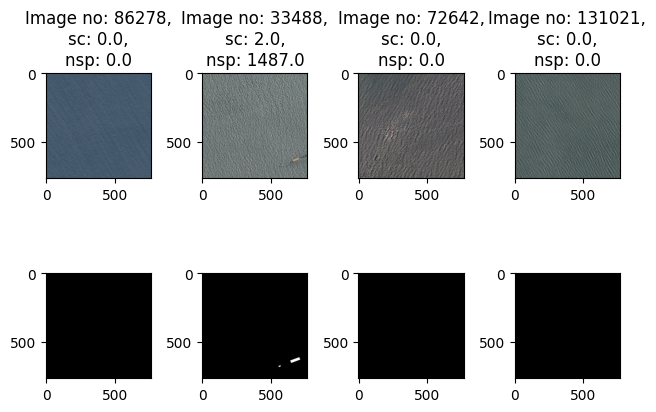

In [70]:
import matplotlib.pyplot as plt
import random
import torch

shape: tuple[int, int] = (2, 4)
fig, axes = plt.subplots(shape[0], shape[1])

for j in range(shape[1]):
    random_index = random.randint(0, len(TrainingDataset))
    image, mask, sc, nsp = TrainingDataset[random_index]
    axes[0, j].imshow(image, cmap = "viridis")
    axes[1, j].imshow(mask, cmap = "grey")
    axes[0, j].set_title(f"Image no: {random_index},\nsc: {sc},\nnsp: {nsp}")
plt.tight_layout()
plt.show()

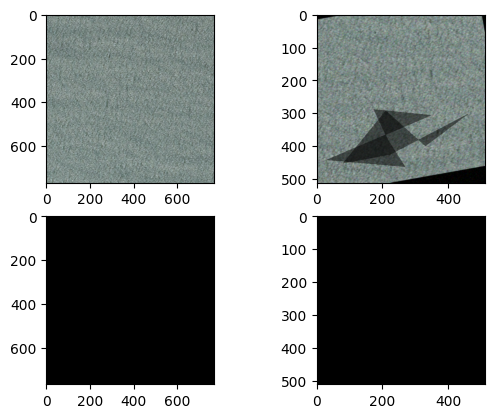

In [71]:
import torch

fig_2, axes_2 = plt.subplots(2, 2)
means = torch.Tensor([[[0.485, 0.456, 0.406]]])
stds = torch.Tensor([[[0.229, 0.224, 0.225]]])

def Denormalize(image: torch.Tensor) -> torch.Tensor:
    image = image * stds.permute(2, 0, 1) + means.permute(2, 0, 1)
    return image

random_index = random.randint(0 , len(TrainingDataset))
img, mask, sc, nps = TrainingDataset[random_index]
axes_2[0, 0].imshow(img)
axes_2[1, 0].imshow(mask, cmap = "grey")

argmt = train_tf(image = img, mask = mask)
axes_2[0, 1].imshow(Denormalize(argmt["image"]).permute(1, 2, 0))
axes_2[1, 1].imshow(argmt["mask"], cmap = "grey")

In [72]:
TrainingDataset.transform = train_tf
ValidationDataset.transform = test_tf

In [73]:
import torchvision.models as models
models.resnext50_32x4d()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1

In [74]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [75]:
import torch
from torch import nn



class AttentionGate(nn.Module):

    def __init__(self, nxic: int, nsic: int, niic: int):
        super().__init__()
        self.xConv = nn.Sequential(
            nn.Conv2d(nxic, niic, kernel_size = 1, stride = 1, padding = 0, bias = True),
            nn.BatchNorm2d(niic)
        )
        
        self.skipConv = nn.Sequential(
            nn.Conv2d(nsic, niic, kernel_size = 1, stride = 1, padding = 0, bias = True),
            nn.BatchNorm2d(niic)
        )
        
        self.final_conv = nn.Sequential(
            nn.Conv2d(niic, 1, kernel_size = 1, stride = 1, padding = 0, bias = True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace = True)
        
    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        
        x_out = self.xConv(x)
        skip_out = self.skipConv(skip)
        weight = self.final_conv(self.relu(x_out + skip_out))
        return skip * weight
        
class DecoderBlock(nn.Module):

    def __init__(self, nxic: int , nsic: int, noc: int):
        super().__init__()
        
        self.attention = AttentionGate(nxic , nsic, (nxic + nsic)//2)
        self.convblock = nn.Sequential(
            nn.Conv2d(nxic + nsic , noc , kernel_size = 3, stride = 1, padding = 1, bias = False),
            nn.BatchNorm2d(noc),
            nn.ELU(inplace = True),

            nn.Conv2d(noc, noc, kernel_size = 3, stride = 1, padding = 1, bias= False),
            nn.BatchNorm2d(noc),
            nn.ELU(inplace = True)
        )
    def forward(self, x: torch.Tensor , skip: torch.Tensor) -> torch.Tensor:
        
        skip = self.attention(x, skip)
        x = torch.cat([x, skip], dim = 1)
        x = self.convblock(x)
        
        return x

class AttentionUnet(nn.Module):

    def __init__(self):
        
        super().__init__()
        weights = models.ResNeXt50_32X4D_Weights.DEFAULT
        self.backbone = models.resnext50_32x4d(weights = weights)
        
        self.backbone.fc = nn.Identity()
        self.backbone.layer4 = nn.Identity()
        
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        for param in self.backbone.layer3.parameters():
            param.requires_grad = True
            
        self.bottleneck = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size = 3, stride = 1, padding = 1, bias = False),
            nn.BatchNorm2d(512),
            nn.ELU(inplace = True),

            nn.Conv2d(512, 1024, kernel_size = 3, stride = 1, padding = 1, bias = False),
            nn.BatchNorm2d(1024),
            nn.ELU(inplace = True)
        )
        
        self.decoder_l3 = DecoderBlock(1024, 1024, 512)
        self.decoder_l2 = DecoderBlock(512, 512, 256)
        self.decoder_l1 = DecoderBlock(256, 256, 64)
        self.decoder_l0 = DecoderBlock(64, 64, 16)
        self.final_conv = nn.Conv2d(16, 1, kernel_size = 3, stride = 1, padding = 1, bias = True)
        self.upsample = nn.Upsample(scale_factor = 2, mode = "bilinear", align_corners = True)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:

        b1 = self.backbone.conv1(x)     # 256 x 256
        b1 = self.backbone.bn1(b1)      # 256 x 256
        b1 = self.backbone.relu(b1)     # 256 x 256
        p1 = self.backbone.maxpool(b1)  # 128 x 128

        b2 = self.backbone.layer1(p1)   # 128 x 128
        b3 = self.backbone.layer2(b2)   # 64 x 64
        b4 = self.backbone.layer3(b3)   # 32 x 32
        
        x  = self.bottleneck(b4)        # 32 x 32
        
        x  = self.decoder_l3(x, b4)   
        x  = self.upsample(x)          # 64 x 64
        x  = self.decoder_l2(x, b3)    
        x  = self.upsample(x)          # 128 x 128
        x  = self.decoder_l1(x, b2)    
        x  = self.upsample(x)          # 256 x 256
        x  = self.decoder_l0(x, b1)    
        x  = self.upsample(x)          # 512 x 512
        x  = self.final_conv(x)
        return x

def DefaultWeighter(ns: torch.Tensor, nsp: torch.Tensor, positive_weight: float = 1.0) -> torch.Tensor:

    with torch.no_grad():
        mask = ns > 0
        weights = torch.ones_like(ns, device = device).to(torch.float32)
        weights[mask] = positive_weight
        weights[mask] += torch.log( (512 * 512 * ns[mask]) / nsp[mask])
        weights[mask] = torch.clamp(weights[mask], min = 1.0, max = 20.0)
    return weights
    
class SegmentLoss(nn.Module):

    def __init__(self, 
                 gamma: float = 2.0,
                 smoothing: float = 1.0,
                 focal_weight: float = 2.0,
                 iou_weight: float= 1.0,
                 pos_weight: float = 4.0,
                 positive_weight: float = 10.0,
                 sample_weighter = DefaultWeighter):
        
        super().__init__()
        
        self.gamma = gamma
        self.smoothing = smoothing
        self.sample_weighter = sample_weighter
        self.focal_weight  = focal_weight
        self.iou_weight = iou_weight
        self.pos_weight = pos_weight
        self.positive_weight = positive_weight
        
        self.flatten = nn.Flatten()
        self.bce = nn.BCEWithLogitsLoss(reduction = "none")
        self.sig = nn.Sigmoid()
        
    def forward(self, preds: torch.Tensor, 
                      targets: torch.Tensor, 
                      ns: torch.Tensor, 
                      nsp: torch.Tensor) -> tuple[torch.Tensor, float, float]:
        
        with torch.amp.autocast('cuda', dtype = torch.float32):

            # This will flatten the preds and targets (B, 1, W, H) => (B, H * W)
            preds_flat = self.flatten(preds)
            targets_flat = self.flatten(targets)

            # Apply bce with raw logits and find focal loss
            bce = self.bce(preds_flat, targets_flat)
            pt = torch.exp(-bce)
            preds_flat = self.sig(preds_flat)
            alpha = torch.abs((preds_flat > 0.5).to(torch.float32) - targets_flat).sum(dim = 1)
            alpha = torch.clamp(alpha, min = 1, max = 10.0)
            focal_loss = ((1 - pt)**self.gamma * bce).mean(dim = 1)
            
            # Track the raw loss
            raw_focal    = focal_loss.mean().item()
            # Then weighten the loss
            focal_loss = alpha * focal_loss
            
            # Find the iou loss
            intersection = (preds_flat * targets_flat).sum(dim = 1)
            total        = (preds_flat + targets_flat).sum(dim = 1)
            union        = total - intersection
            iou_loss     = 1 - (intersection + self.smoothing )/(union + self.smoothing)

            # Track the raw loss , necessary for later visualization
            raw_iou      = iou_loss.mean().item()

            # Weighten the focal loss and iou loss seperately
            focal_loss   *= self.focal_weight
            iou_loss     *= self.iou_weight

            # Find the weights based on num_ships and num_ship_pixels
            if self.sample_weighter is not None:
                weights: torch.Tensor = self.sample_weighter(ns, nsp, self.positive_weight)
            else:
                weights: torch.Tensor = nn.ones_like(preds, device = device)
                
            # Finally weighten and return!
        return (weights * (iou_loss + focal_loss)).mean(), raw_iou, raw_focal

In [76]:
import torch.nn.init as init
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import GradScaler

num_epochs = 3
def init_layer(layer: nn.Module) -> None:

    if isinstance(layer, nn.Conv2d):
        init.xavier_uniform_(layer.weight)
        if layer.bias is not None:
            init.zeros_(layer.bias)

model: AttentionUnet = AttentionUnet()
param_group: list[dict] = [
    {"params": model.backbone.layer3.parameters(), "lr": 3e-5},
    {"params": model.bottleneck.parameters(), "lr": 1e-4},
    {"params": model.decoder_l3.parameters(), "lr": 1e-4},
    {"params": model.decoder_l2.parameters(), "lr": 1e-4},
    {"params": model.decoder_l1.parameters(), "lr": 1e-4},
    {"params": model.decoder_l0.parameters(), "lr": 1e-4},
    {"params": model.final_conv.parameters(), "lr": 2e-4},
]

num_pos_samples: int = (dataset.mask_infos["ShipCounts"] > 0).sum()
num_samples: int = len(dataset.mask_infos)

optimizer: AdamW     = AdamW(param_group, lr = 2e-4, weight_decay = 5e-3)
scheduler: CosineAnnealingLR = CosineAnnealingLR(optimizer, T_max = num_epochs * 1.5 , eta_min = 2e-5)

pos_weight = min(num_samples/num_pos_samples, 10.0)
criterion: SegmentLoss = SegmentLoss(positive_weight = pos_weight)
evaluator: SegmentLoss = SegmentLoss(sample_weighter = None, positive_weight = pos_weight)
grad_scaler: GradScaler = GradScaler('cuda')

In [77]:
from torch.utils.data import DataLoader

batch_size = 16
TrainingLoader: DataLoader = DataLoader(TrainingDataset, 
                                        batch_size = batch_size,  
                                        num_workers = 4, 
                                        pin_memory = True,
                                        shuffle    = True,
                                        persistent_workers = True)

ValidationLoader: DataLoader = DataLoader(ValidationDataset,
                                          batch_size = batch_size,
                                          num_workers = 4,
                                          pin_memory = True,
                                          shuffle = True,
                                          persistent_workers = True)


In [78]:
model.to(device)
criterion.to(device)
evaluator.to(device)

model.decoder_l0.apply(init_layer)
model.decoder_l1.apply(init_layer)
model.decoder_l2.apply(init_layer)
model.decoder_l3.apply(init_layer)
model.final_conv.apply(init_layer)

Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [79]:
from tqdm import tqdm as ProgressBarView

epoch_history: dict = {
    "BatchIdx": [],
    "BWTrainIoU": [],
    "BWTrainFocal": [],
    "BWWeightedLossT": [],
    "BWValIoU": [],
    "BWValFocal": [],
    "BWWeightedLossV": []
}
best_loss: float = float("inf")
ckpoint_path = "best_model.pth"

for epoch_no in range(num_epochs):
    print("\n-------------------------------------------------")
    print(f"Epoch no {epoch_no} started! ")
    model.train(True)

    pbar = ProgressBarView(TrainingLoader)
    for batch_idx, (imgs, lbls, ns_s, nsp_s) in enumerate(pbar):
        if (epoch_no + 1) % 4 == 0:
            optimizer.zero_grad()
            
        imgs = imgs.to(device)
        lbls = lbls.to(device)
        ns_s = ns_s.to(device)
        nsp_s = nsp_s.to(device)
        
        with torch.amp.autocast( 'cuda' ,dtype = torch.float16):
            preds = model(imgs)
            loss, iou, focal = criterion(preds, lbls, ns_s, nsp_s)
            
        grad_scaler.scale(loss).backward()
        if (epoch_no + 1) % 4 == 0:
            grad_scaler.step(optimizer)
            grad_scaler.update()
            
        epoch_history["BatchIdx"].append(batch_idx)
        epoch_history["BWWeightedLossT"].append(loss.item())
        epoch_history["BWTrainIoU"].append(iou)
        epoch_history["BWTrainFocal"].append(focal)
        pbar.set_postfix({
            "iou": f"{iou :.3f}",
            "focal": f"{focal :.3f}",
            "w_loss": f"{loss.item() :.3f}"
        })
    model.eval()
    
    avg_weighted_val_loss: float = 0.0

    pbar = ProgressBarView(ValidationLoader)
    with torch.no_grad():
        for batch_idx, (imgs, lbls, ns_s, nsp_s) in enumerate(pbar):
        
            imgs = imgs.to(device)
            lbls = lbls.to(device)
            ns_s = ns_s.to(device)
            nsp_s = nsp_s.to(device)
            
            with torch.amp.autocast('cuda',dtype = torch.float16):
                preds = model(imgs)
                loss, iou, focal = evaluator(preds, lbls, ns_s, nsp_s)
                
            epoch_history["BatchIdx"].append(batch_idx)
            epoch_history["BWWeightedLossV"].append(loss.item())
            epoch_history["BWValIoU"].append(iou)
            epoch_history["BWValFocal"].append(focal)
            avg_weighted_val_loss += loss.item()/len(ValidationLoader)
            pbar.set_postfix({
                "iou": f"{iou :.3f}",
                "focal": f"{focal :.3f}",
                "w_loss": f"{loss.item() :.3f}"
            })
    
    if best_loss > avg_weighted_val_loss:
        best_loss = avg_weighted_val_loss
        ckpnt: dict = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch_no": epoch_no,
            "loss": best_loss
        }
        torch.save(ckpnt, ckpoint_path)
        print("New best model found!")
    print("\n-------------------------------------------------")


-------------------------------------------------
Epoch no 0 started! 


 20%|█▉        | 1660/8425 [1:43:42<7:02:38,  3.75s/it, iou=1.000, focal=0.232, w_loss=24.645] 


KeyboardInterrupt: 